### TUGAS BESAR MATA KULIAH PENAMBANGAN DATA DETEKSI FRAUD TRANSAKSI KARTU KREDIT MENGGUNAKAN KOMPARASI ALGORITMA LOGISTIC REGRESSION, NAIVE BAYES, DAN RANDOM FOREST

### Latar Belakang

Tugas Besar ini berfokus pada analisis data transaksi kartu kredit (~284.807 transaksi) untuk mendeteksi transaksi fraud serta membandingkan performa tiga algoritma supervised learning (Logistic Regression, Naive Bayes, dan Random Forest Classifier).

**Fokus Analisis:**

1. Memahami karakteristik transaksi normal vs fraud melalui Eksplorasi Data (EDA).
2. Menangani ketidakseimbangan kelas (*class imbalance*) yang ekstrem menggunakan teknik SMOTE.
3. Membandingkan performa algoritma supervised learning (Logistic Regression, Naive Bayes, dan Random Forest).
4. Melakukan validasi kluster alami tanpa label (*unsupervised clustering*) menggunakan K-Means Clustering (k=2) & PCA 2D.
5. Membangun aplikasi dashboard interaktif Streamlit untuk simulasi deteksi fraud secara real-time.


### Pengumpulan Data Awal

Tahap awal untuk memuat pustaka (library) dan membaca dataset mentah.


### Install Library yang Dibutuhkan

Menginstal library dasar yang dibutuhkan seperti Streamlit untuk dashboard dan Pyngrok untuk tunneling.


In [45]:
%pip install pandas>=2.2.3 matplotlib>=3.9.0 scikit-learn>=1.5.0 imbalanced-learn>=0.12.3 seaborn>=0.13.2 streamlit pyngrok

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### Mengimpor Pustaka Utama (Library Prerequisites)

Mengimpor library analisis data (Pandas, Numpy), visualisasi (Matplotlib, Seaborn), data preprocessing, clustering (K-Means), dan pemodelan machine learning (Logistic Regression, Naive Bayes, Random Forest).


In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st
import joblib
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression    
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
import time
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

### Load Dataset

Dataset dibaca dari file CSV (`creditcard.csv`) kemudian disimpan ke dalam DataFrame agar dapat diproses menggunakan Pandas.


In [47]:
df = pd.read_csv('creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Menampilkan Pesan Konfirmasi dan Ukuran Struktur Dimensi Data Awal

Melihat ukuran baris dan kolom dataset. Terdiri dari 284.807 baris transaksi dan 31 kolom fitur.


In [48]:
print(f"Jumlah Total Baris (Records/Instances) : {df.shape[0]:,}")
print(f"Jumlah Total Kolom (Features/Attributes): {df.shape[1]}")

Jumlah Total Baris (Records/Instances) : 284,807
Jumlah Total Kolom (Features/Attributes): 31


### Deskripsi Data

Mendeskripsikan tipe data, nama kolom, dan jumlah baris yang tidak bernilai null.


### Menampilkan Tipe Data dan Informasi Non-Null untuk Setiap Atribut

Memeriksa tipe data masing-masing kolom (sebagian besar bertipe float64 hasil transformasi PCA).


In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

# Exploratory Data Analysis (EDA)

Eksplorasi data untuk memahami sebaran kelas, nominal transaksi, waktu, dan korelasi antar fitur.


### Pemeriksaan Nilai Hilang (Missing Values)

Memastikan tidak ada nilai yang kosong (NaN/Null) pada seluruh dataset agar tidak mengganggu pemodelan.


In [50]:
print(df.isnull().sum().sum())

0


### Statistik Deskriptif Atribut Kunci (Time & Amount)

Melihat ringkasan statistik (mean, standar deviasi, min, max) dari fitur waktu dan nominal transaksi.


In [51]:
print(df[['Time', 'Amount']].describe())

                Time         Amount
count  284807.000000  284807.000000
mean    94813.859575      88.349619
std     47488.145955     250.120109
min         0.000000       0.000000
25%     54201.500000       5.600000
50%     84692.000000      22.000000
75%    139320.500000      77.165000
max    172792.000000   25691.160000


### Analisis Kuantitatif Distribusi Kelas Target (Class)

Menghitung jumlah kelas target. Data sangat tidak seimbang (imbalance): 99.83% Normal dan hanya 0.17% Fraud.


In [52]:
print(df['Class'].value_counts())
print(df['Class'].value_counts(normalize=True) * 100)

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


### Visualisasi Distribusi Kelas Target (Bar Chart)

Membuat grafik batang perbandingan jumlah data normal vs fraud dengan skala logaritmik agar kelas minoritas (fraud) tetap terlihat.


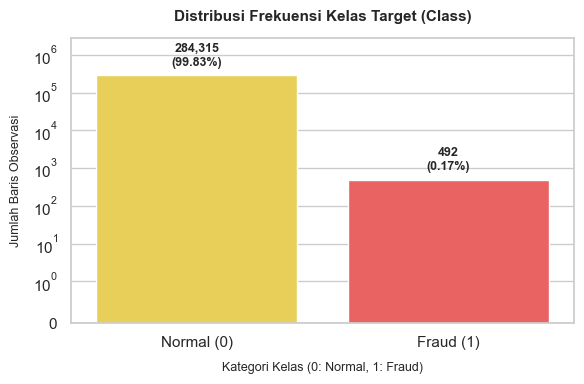

In [53]:
total_data = len(df)
class_counts = df['Class'].value_counts()

plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df, palette=['#ffde42', '#ff4d4d'])
plt.title('Distribusi Frekuensi Kelas Target (Class)', fontsize=11, fontweight='bold', pad=12)
plt.yscale('symlog', linthresh=1.0)
plt.xlabel('Kategori Kelas (0: Normal, 1: Fraud)', fontsize=9, labelpad=8)
plt.ylabel('Jumlah Baris Observasi', fontsize=9, labelpad=8)
plt.xticks([0, 1], ['Normal (0)', 'Fraud (1)'])
plt.ylim(0, total_data * 10)

for i, count in enumerate(class_counts):
    persentase = (count / total_data) * 100
    plt.text(x=i, y=count * 1.5, s=f"{count:,}\n({persentase:.2f}%)", 
             ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

### Visualisasi Distribusi Fitur Amount (Histogram/KDE Plot)

Melihat distribusi nominal transaksi yang menunjukkan mayoritas transaksi bernilai kecil (skewed ke kanan).


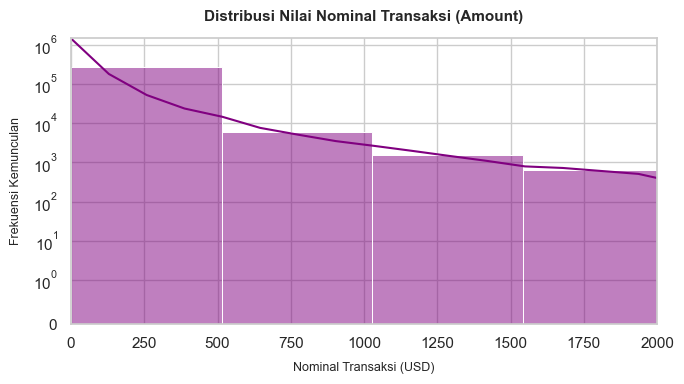

In [54]:
plt.figure(figsize=(7, 4))
sns.histplot(df['Amount'], bins=50, kde=True, color='purple')
plt.title('Distribusi Nilai Nominal Transaksi (Amount)', fontsize=11, fontweight='bold', pad=12)
plt.yscale('symlog', linthresh=1.0)
plt.xlabel('Nominal Transaksi (USD)', fontsize=9, labelpad=8)
plt.ylabel('Frekuensi Kemunculan', fontsize=9, labelpad=8)
plt.xlim([0, 2000]) 
plt.tight_layout()
plt.show()

### Visualisasi Distribusi Fitur Time (Histogram/KDE Plot)

Melihat grafik kerapatan waktu transaksi yang menunjukkan pola berulang (menurun di malam hari/jam tidur dan meningkat di siang hari).


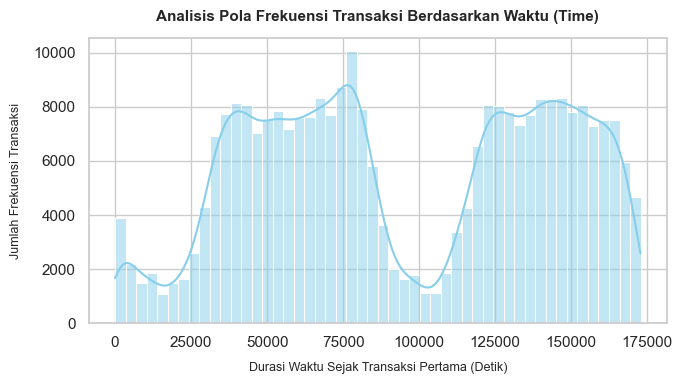

In [55]:
plt.figure(figsize=(7, 4))
sns.histplot(df['Time'], bins=50, kde=True, color='skyblue')
plt.title('Analisis Pola Frekuensi Transaksi Berdasarkan Waktu (Time)', fontsize=11, fontweight='bold', pad=12)
plt.xlabel('Durasi Waktu Sejak Transaksi Pertama (Detik)', fontsize=9, labelpad=8)
plt.ylabel('Jumlah Frekuensi Transaksi', fontsize=9, labelpad=8)
plt.tight_layout()
plt.show()

### Visualisasi Distribusi Fitur Amount (Boxplot)

Membuat boxplot untuk melihat persebaran nominal transaksi dan mendeteksi pencilan (outliers).


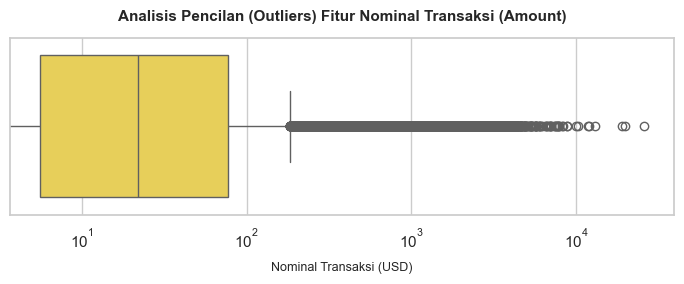

In [56]:
plt.figure(figsize=(7, 3))
sns.boxplot(x=df['Amount'], color='#ffde42')
plt.xscale('log')
plt.title('Analisis Pencilan (Outliers) Fitur Nominal Transaksi (Amount)', fontsize=11, fontweight='bold', pad=12)
plt.xlabel('Nominal Transaksi (USD)', fontsize=9, labelpad=8)
plt.tight_layout()
plt.show()

### Visualisasi Boxplot Distribusi Fitur Laten Berdasarkan Kelas Target (Class)

Membuat visualisasi sebaran nilai fitur laten V3 pada kelas normal vs fraud untuk melihat perbedaan perilaku.


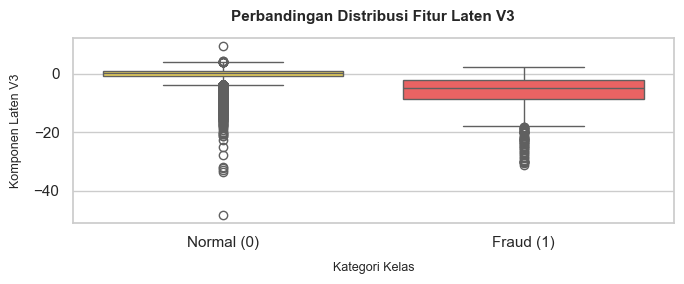

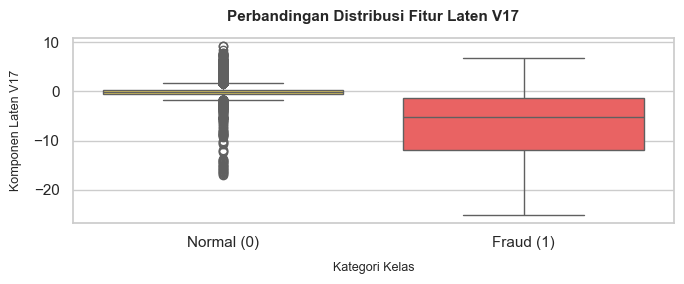

In [57]:
plt.figure(figsize=(7, 3))
sns.boxplot(x='Class', y='V3', data=df, palette=['#ffde42', '#ff4d4d'])
plt.title('Perbandingan Distribusi Fitur Laten V3', fontsize=11, fontweight='bold', pad=12)
plt.xlabel('Kategori Kelas', fontsize=9, labelpad=8)
plt.ylabel('Komponen Laten V3', fontsize=9, labelpad=8)
plt.xticks([0, 1], ['Normal (0)', 'Fraud (1)'])
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 3))
sns.boxplot(x='Class', y='V17', data=df, palette=['#ffde42', '#ff4d4d'])
plt.title('Perbandingan Distribusi Fitur Laten V17', fontsize=11, fontweight='bold', pad=12)
plt.xlabel('Kategori Kelas', fontsize=9, labelpad=8)
plt.ylabel('Komponen Laten V17', fontsize=9, labelpad=8)
plt.xticks([0, 1], ['Normal (0)', 'Fraud (1)'])
plt.tight_layout()
plt.show()

### Analisis Multivariat: Korelasi Heatmap untuk Fitur Sampel

Melihat hubungan korelasi antar fitur laten (V1-V28), nominal (Amount), dan target (Class) menggunakan heatmap korelasi.


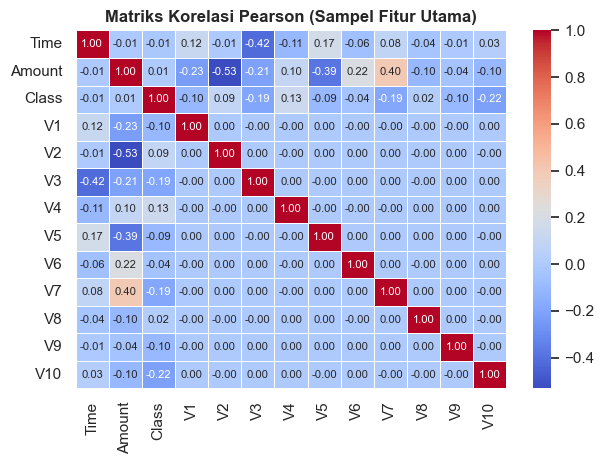

In [58]:
fitur_sampel = ['Time', 'Amount', 'Class', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10']
corr_matrix = df[fitur_sampel].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, cbar=True, annot_kws={'size': 8})
plt.title('Matriks Korelasi Pearson (Sampel Fitur Utama)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Analisis Multivariat: Scatter Plot Fitur Laten V3 vs Amount

Memetakan hubungan antara fitur laten V3 dengan nominal transaksi (Amount) berdasarkan kelas target.


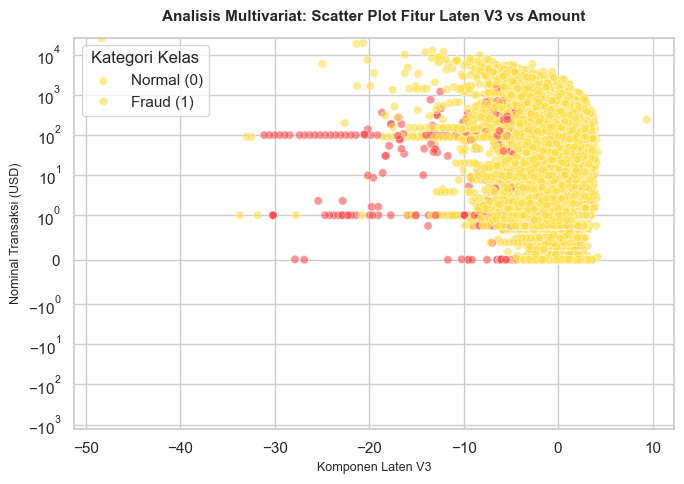

In [59]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x='V3', y='Amount', hue='Class', data=df, palette=['#ffde42', '#ff4d4d'], alpha=0.6)
plt.yscale('symlog', linthresh=1.0)
plt.title('Analisis Multivariat: Scatter Plot Fitur Laten V3 vs Amount', fontsize=11, fontweight='bold', pad=12)
plt.xlabel('Komponen Laten V3', fontsize=9)
plt.ylabel('Nominal Transaksi (USD)', fontsize=9)
plt.legend(title='Kategori Kelas', labels=['Normal (0)', 'Fraud (1)'])
plt.tight_layout()
plt.show()

### Analisis Multivariat: Scatter Plot Antar Component Laten (V1 vs V2)

Membuat scatter plot antara V1 dan V2 untuk melihat pengelompokan alami antara transaksi normal dan fraud.


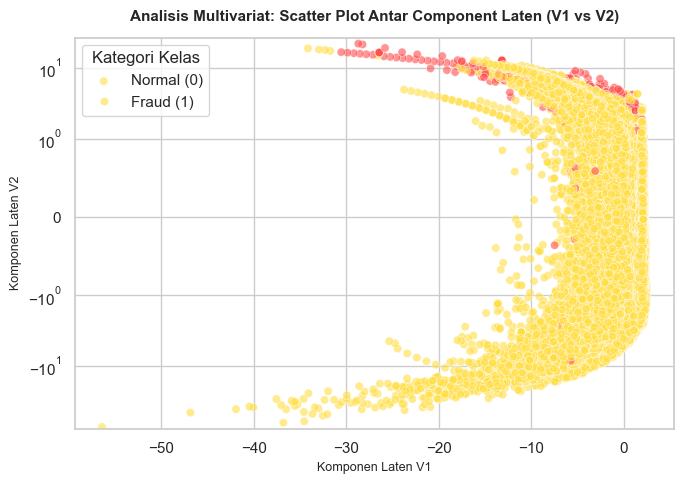

In [60]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x='V1', y='V2', hue='Class', data=df, palette=['#ffde42', '#ff4d4d'], alpha=0.6)
plt.title('Analisis Multivariat: Scatter Plot Antar Component Laten (V1 vs V2)', fontsize=11, fontweight='bold', pad=12)
plt.yscale('symlog', linthresh=1.0)
plt.xlabel('Komponen Laten V1', fontsize=9)
plt.ylabel('Komponen Laten V2', fontsize=9)
plt.legend(title='Kategori Kelas', labels=['Normal (0)', 'Fraud (1)'])
plt.tight_layout()
plt.show()

### Kualitas Data

Melakukan pengecekan kualitas data seperti kebersihan data dari missing values, duplikasi, dan pencilan.


### Identifikasi dan Perhitungan Persentase Nilai Hilang (Missing Values)

Menghitung total persentase nilai kosong di setiap kolom untuk memastikan kebersihan data.


In [61]:
missing_count = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Total Missing': missing_count, 'Percentage (%)': missing_percentage})

missing_cols = missing_count[missing_count > 0].index

if len(missing_cols) > 0:
    print("Ditemukan missing value. Melakukan imputasi...")
    for col in missing_cols:
        if df[col].dtype in ['float64', 'int64']:
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])
    print("Proses imputasi selesai menggunakan nilai Median & Mode.")
else:
    print("Tidak ada missing value di semua kolom. Imputasi (Median/Mode) tidak perlu dieksekusi.")

Tidak ada missing value di semua kolom. Imputasi (Median/Mode) tidak perlu dieksekusi.


### Identifikasi Jumlah Data Duplikat

Menghitung jumlah baris data yang terduplikasi secara identik agar bisa dibersihkan pada tahap preprocessing.


In [62]:
duplicate_count = df.duplicated().sum()
print(f"Jumlah baris data yang duplikat: {duplicate_count} baris")

Jumlah baris data yang duplikat: 1081 baris


### Identifikasi Outliers dengan Metode IQR pada Fitur Utama (Amount)

Mengidentifikasi data pencilan ekstrem pada kolom nominal belanja (Amount) menggunakan Interquartile Range (IQR).


In [63]:
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Amount'] < lower_bound) | (df['Amount'] > upper_bound)]
print(f"Batas Bawah Outlier (Lower Bound): {lower_bound}")
print(f"Batas Atas Outlier (Upper Bound) : {upper_bound}")
print(f"Jumlah Data Outliers pada Amount  : {len(outliers)} baris")
print(f"Persentase Outliers pada Amount  : {(len(outliers) / len(df)) * 100:.2f}%")

Batas Bawah Outlier (Lower Bound): -101.7475
Batas Atas Outlier (Upper Bound) : 184.5125
Jumlah Data Outliers pada Amount  : 31904 baris
Persentase Outliers pada Amount  : 11.20%


### Visualisasi Outliers Menggunakan Boxplot pada Fitur Amount

Visualisasi visual letak pencilan (outliers) pada fitur Amount.


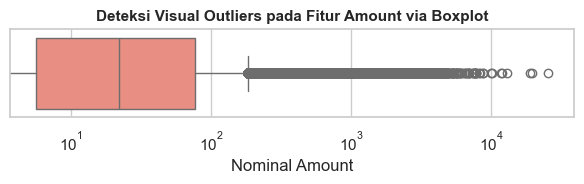

In [64]:
plt.figure(figsize=(6, 2))
sns.boxplot(x=df['Amount'], color='salmon')
plt.xscale('log')
plt.title('Deteksi Visual Outliers pada Fitur Amount via Boxplot', fontsize=11, fontweight='bold')
plt.xlabel('Nominal Amount')
plt.tight_layout()
plt.show()

### Pemilihan Data (Data Selection)

Proses seleksi data untuk memilih fitur-fitur terbaik dan membuang fitur yang memiliki multikolinearitas.


### Menghitung Matriks Korelasi untuk Seluruh Fitur Prediktor

Menghitung matriks korelasi antar fitur prediktor independen untuk mendeteksi multikolinearitas.


In [65]:
fitur_independen = df.drop(columns=['Class'])
matriks_korelasi = fitur_independen.corr().abs()

### Mengidentifikasi Pasangan Fitur yang Memiliki Multikolinearitas Tinggi (> 0.90)

Menyaring pasangan fitur yang berkorelasi sangat kuat (> 0.90) karena dapat mengganggu kestabilan model statistik.


In [66]:
segitiga_atas = matriks_korelasi.where(np.triu(np.ones(matriks_korelasi.shape), k=1).astype(bool))
fitur_multikolinear = [kolom for kolom in segitiga_atas.columns if any(segitiga_atas[kolom] > 0.90)]

### Menampilkan Hasil Identifikasi Seleksi Data

Menampilkan kesimpulan deteksi multikolinearitas (tidak ada fitur yang melebihi batas 0.90, sehingga semua fitur aman dipertahaman).


In [67]:
print(f"Jumlah fitur yang terdeteksi multikolinear (> 0.90): {len(fitur_multikolinear)}")
if len(fitur_multikolinear) > 0:
    print(f"Fitur yang direkomendasikan untuk dihapus: {fitur_multikolinear}")
else:
    print("Tidak ditemukan fitur yang mengalami multikolinearitas tinggi.")

Jumlah fitur yang terdeteksi multikolinear (> 0.90): 0
Tidak ditemukan fitur yang mengalami multikolinearitas tinggi.


### Visualisasi Hasil Pemeriksaan Multikolinearitas

Visualisasi heatmap korelasi antar variabel prediktor untuk verifikasi tidak adanya multikolinearitas.


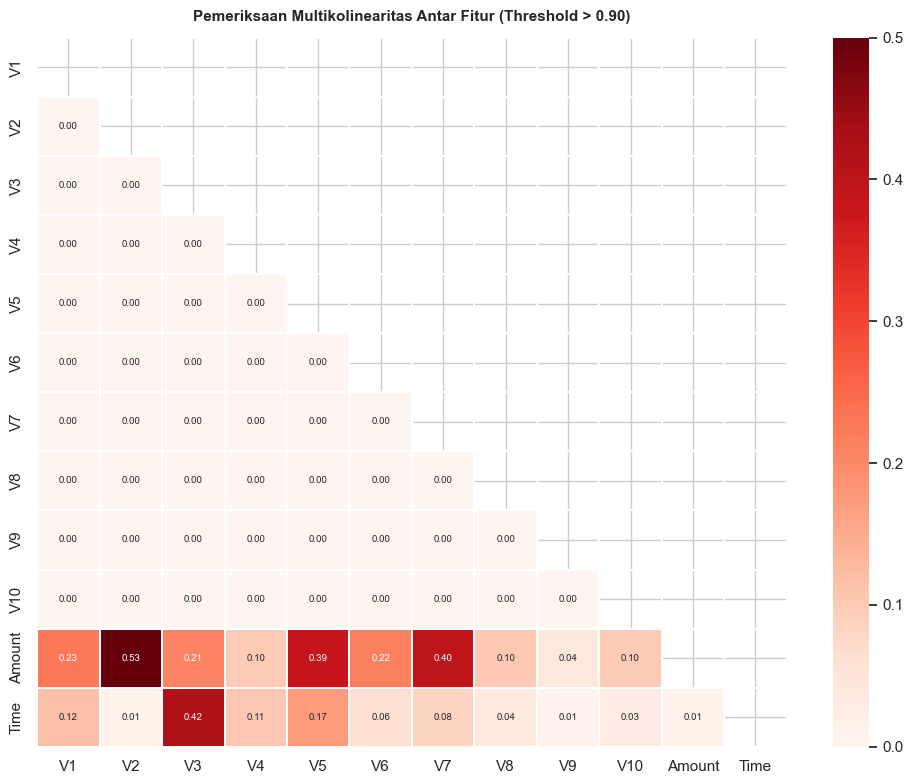

In [68]:
top_features = ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'Amount', 'Time']
corr_sub = df[top_features].corr().abs()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_sub, dtype=bool))
sns.heatmap(corr_sub, mask=mask, annot=True, fmt='.2f',
            cmap='Reds', linewidths=0.3, annot_kws={'size': 7},
            vmax=0.5, cbar=True)
plt.title('Pemeriksaan Multikolinearitas Antar Fitur (Threshold > 0.90)', 
          fontsize=11, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

### Melakukan Replika Data Frame untuk Memastikan Data Awal Tetap Aman

Menyalin DataFrame asli ke variabel baru (df_clean) untuk menghindari kerusakan pada data mentah.


In [69]:
df_selected = df.copy()
print(f"Jumlah baris: {df_selected.shape[0]}")
print(f"Jumlah kolom: {df_selected.shape[1]}")

Jumlah baris: 284807
Jumlah kolom: 31


### Pembersihan Data (Data Cleansing)

Melakukan penghapusan data duplikat dan penanganan pencilan.


### Eksekusi Pembersihan Data Duplikat (Drop Duplicates)

Menghapus baris duplikat yang teridentifikasi agar data yang digunakan unik.


In [70]:
df_cleansed = df_selected.drop_duplicates()

### Penanganan Pencilan (Outliers) dengan Transformasi Log1p

Mentransformasikan fitur Amount dengan fungsi logaritma log1p untuk memperkecil rentang pencilan ekstrem dan menormalkan sebaran.


In [71]:
df_selected['log_Amount_before'] = np.log1p(df_selected['Amount'])
df_cleansed['log_Amount_after'] = np.log1p(df_cleansed['Amount'])

### Visualisasi Boxplot Sebelum dan Sesudah Sesuai Acuan Batas Distribusi

Perbandingan sebaran fitur Amount sebelum dan sesudah transformasi logaritma.


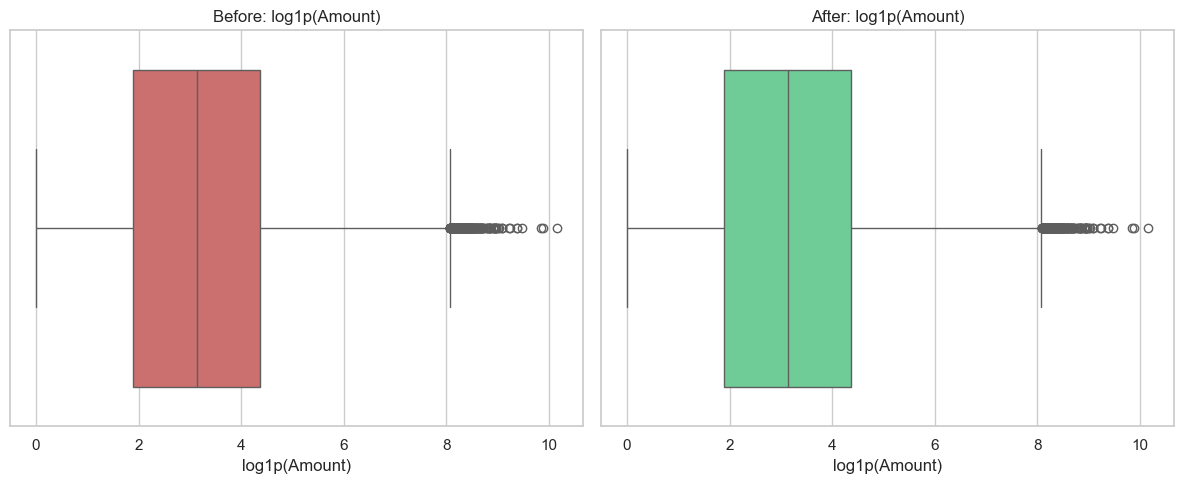

In [72]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x=df_selected['log_Amount_before'], color='#db5f5f')
plt.title('Before: log1p(Amount)', fontsize=12)
plt.xlabel('log1p(Amount)')

plt.subplot(1, 2, 2)
sns.boxplot(x=df_cleansed['log_Amount_after'], color='#5fdb94')
plt.title('After: log1p(Amount)', fontsize=12)
plt.xlabel('log1p(Amount)')

plt.tight_layout()
plt.show()

### Menampilkan Informasi Hasil Pembersihan Logika Baris

Mengecek dimensi akhir dari dataset bersih setelah dilakukan drop duplicates.


In [73]:
print(f"Jumlah Baris Sebelum Pembersihan : {df_selected.shape[0]:,}")
print(f"Jumlah Baris Setelah Pembersihan  : {df_cleansed.shape[0]:,}")
print(f"Total Baris Duplikat Dieliminasi  : {df_selected.shape[0] - df_cleansed.shape[0]:,}")

Jumlah Baris Sebelum Pembersihan : 284,807
Jumlah Baris Setelah Pembersihan  : 283,726
Total Baris Duplikat Dieliminasi  : 1,081


# Rekayasa Fitur (Feature Engineering)

Tahap memodifikasi atau membuat fitur baru dari fitur yang sudah ada agar lebih informatif bagi model.


### Ekstraksi Fitur (Feature Extraction) dari Atribut Kontinu 'Time'

Mengonversi fitur detik akumulatif 'Time' menjadi format jam dalam satu hari (0-23 jam).


In [74]:
df_engineered = df_cleansed.copy()

df_engineered['Hour_of_Day'] = (df_engineered['Time'] / 3600) % 24
df_engineered['Hour_of_Day'] = df_engineered['Hour_of_Day'].astype(int)

### Konstruksi Fitur Baru (Feature Creation) & Pengelompokan Data (Binning)

Melakukan binning (pengelompokan jam) menjadi 4 sesi waktu: Dini Hari, Pagi, Siang, dan Malam.


In [75]:
batasan_bin = [-1, 5, 11, 17, 23]
label_bin = [0, 1, 2, 3]

df_engineered['Time_Session'] = pd.cut(df_engineered['Hour_of_Day'],
                                       bins=batasan_bin,
                                       labels=label_bin).astype(int)

### Menampilkan Hasil Rekayasa Fitur pada Sampel Dataset

Menampilkan data sampel untuk memastikan fitur jam baru dan sesi waktu baru terbentuk dengan benar.


In [76]:
print("Verifikasi Hasil Rekayasa Fitur")
print(df_engineered[['Time', 'Hour_of_Day', 'Time_Session', 'Amount', 'Class']].head())

print("\nDistribusi Hasil Rekayasa Fitur")
print(df_engineered['Time_Session'].value_counts().sort_index())

Verifikasi Hasil Rekayasa Fitur
   Time  Hour_of_Day  Time_Session  Amount  Class
0   0.0            0             0  149.62      0
1   0.0            0             0    2.69      0
2   1.0            0             0  378.66      0
3   1.0            0             0  123.50      0
4   2.0            0             0   69.99      0

Distribusi Hasil Rekayasa Fitur
Time_Session
0    23842
1    70643
2    96121
3    93120
Name: count, dtype: int64


### Feature Creation - Binning Time Session (4 Sesi Waktu)

Melakukan One-Hot Encoding pada sesi waktu agar nilainya menjadi biner (0 atau 1) sebelum dilatih.


In [77]:
print("Distribusi sesi waktu hasil rekayasa fitur:")
sesi_counts = df_engineered['Time_Session'].value_counts().sort_index()
sesi_label  = {0: 'Midnight/Dini Hari (00-05)',
               1: 'Morning/Pagi     (06-11)',
               2: 'Afternoon/Siang  (12-17)',
               3: 'Night/Malam      (18-23)'}
for idx, count in sesi_counts.items():
    print(f"  Sesi {idx} - {sesi_label[idx]}: {count:,} transaksi")

Distribusi sesi waktu hasil rekayasa fitur:
  Sesi 0 - Midnight/Dini Hari (00-05): 23,842 transaksi
  Sesi 1 - Morning/Pagi     (06-11): 70,643 transaksi
  Sesi 2 - Afternoon/Siang  (12-17): 96,121 transaksi
  Sesi 3 - Night/Malam      (18-23): 93,120 transaksi


### Transformasi dan Pemformatan Data

Penskalaan data numerik dan pembagian dataset.


### Pengodean Variabel Kategorikal & Pemformatan Tipe Data

Memastikan tipe data numerik konsisten bertipe float untuk model.


In [78]:
df_transformed = df_engineered.copy()

le = LabelEncoder()
df_transformed['Time_Session_Label'] = le.fit_transform(df_transformed['Time_Session'])

df_transformed = pd.get_dummies(df_transformed, columns=['Time_Session'], prefix='Session', dtype=int)

### Penskalaan Fitur Numerik (Feature Scaling) menggunakan RobustScaler

Menskalakan kolom Amount menggunakan RobustScaler (berdasarkan median dan IQR) agar tahan terhadap outliers.


In [79]:
scaler = RobustScaler()
df_transformed['Scaled_Amount'] = scaler.fit_transform(df_transformed[['Amount']])

### Menghapus Fitur Asal 'Time' dan 'Amount' yang Sudah Ditransformasikan

Menghapus kolom 'Time' dan 'Amount' lama karena sudah digantikan oleh fitur rekayasa yang baru.


In [80]:
kolom_dihapus = ['Time', 'Amount', 'log_Amount_before', 'log_Amount_after', 'Hour_of_Day', 'Time_Session_Label']
df_final = df_transformed.drop(columns=kolom_dihapus, errors='ignore')

### Pemisahan Data Splitting (Data Pelatihan & Data Pengujian)

Membagi dataset menjadi 80% data training dan 20% data testing.


In [81]:
X = df_final.drop(columns=['Class'])
y = df_final['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Penanganan Ketidakseimbangan Kelas (Class Imbalance) dengan SMOTE

Menerapkan SMOTE hanya pada data training untuk menduplikasi transaksi fraud secara sintetis sehingga jumlahnya seimbang.


In [82]:
print("Kondisi Kelas Sebelum SMOTE (Data Training)")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("\nKondisi Kelas Sesudah SMOTE (Data Training)")
print(y_train_res.value_counts())

print("\nFinalisasi Format dan Dimensi Data Training")
print(f"Dimensi X_train Sesudah SMOTE: {X_train_res.shape}")
print(f"Dimensi y_train Sesudah SMOTE: {y_train_res.shape}")

Kondisi Kelas Sebelum SMOTE (Data Training)
Class
0    226602
1       378
Name: count, dtype: int64

Kondisi Kelas Sesudah SMOTE (Data Training)
Class
0    226602
1    226602
Name: count, dtype: int64

Finalisasi Format dan Dimensi Data Training
Dimensi X_train Sesudah SMOTE: (453204, 33)
Dimensi y_train Sesudah SMOTE: (453204,)


### Visualisasi Distribusi Kelas Sebelum & Sesudah SMOTE

Visualisasi grafik batang perbandingan kelas target sebelum dan sesudah penyeimbangan kelas.


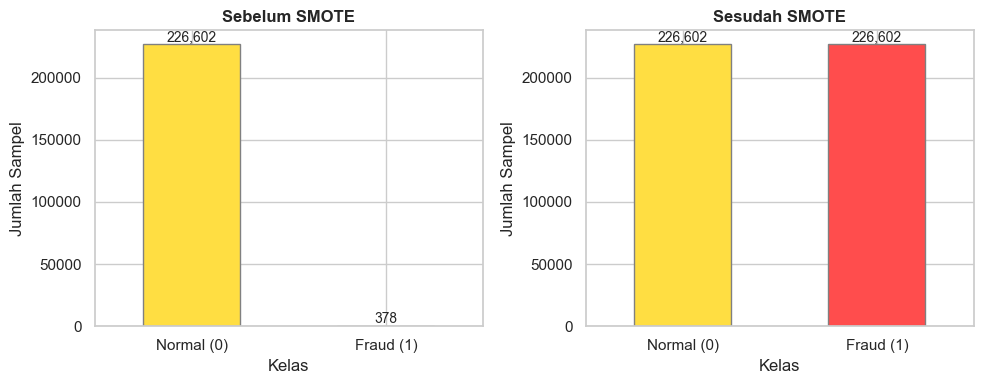

Gambar 15 - Distribusi Kelas Sebelum dan Sesudah SMOTE


In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
y_train.value_counts().plot(
    kind='bar',
    color=['#ffde42', '#ff4d4d'], edgecolor='grey'
)
plt.title('Sebelum SMOTE', fontsize=12, fontweight='bold')
plt.xlabel('Kelas')
plt.ylabel('Jumlah Sampel')
plt.xticks(range(2), ['Normal (0)', 'Fraud (1)'], rotation=0)
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height()):,}',
                       (p.get_x() + p.get_width()/2., p.get_height()),
                       ha='center', va='bottom', fontsize=10)

plt.subplot(1, 2, 2)
pd.Series(y_train_res).value_counts().sort_index().plot(
    kind='bar',
    color=['#ffde42', '#ff4d4d'], edgecolor='grey'
)
plt.title('Sesudah SMOTE', fontsize=12, fontweight='bold')
plt.xlabel('Kelas')
plt.ylabel('Jumlah Sampel')
plt.xticks(range(2), ['Normal (0)', 'Fraud (1)'], rotation=0)
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height()):,}',
                       (p.get_x() + p.get_width()/2., p.get_height()),
                       ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### Pemilihan Teknik Pemodelan

Pendefinisian algoritma klasifikasi yang akan dilatih dan dievaluasi.


### Pendefinisian Model Baseline (Logistic Regression)

Membuat instance model Logistic Regression sebagai model dasar klasifikasi linear.


In [84]:
model_lr = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
print("Proses Training Model Baseline (Logistic Regression)")
mulai_lr = time.time()
model_lr.fit(X_train_res, y_train_res)
selesai_lr = time.time()
durasi_lr = selesai_lr - mulai_lr
print(f"Waktu Training Logistic Regression: {durasi_lr:.4f} detik\n")

y_pred_lr = model_lr.predict(X_test) 

Proses Training Model Baseline (Logistic Regression)
Waktu Training Logistic Regression: 3.2654 detik



### Pendefinisian Model Pembanding (Naive Bayes - GaussianNB)

Membuat instance model Naive Bayes (Gaussian) sebagai pembanding berbasis probabilitas.


In [85]:
model_baseline = GaussianNB()

print("Proses Training Model Pembanding (Naive Bayes)")
mulai_nb = time.time()
model_baseline.fit(X_train_res, y_train_res)
selesai_nb = time.time()
durasi_nb = selesai_nb - mulai_nb
print(f"Waktu Training Naive Bayes: {durasi_nb:.4f} detik\n")

y_pred_nb = model_baseline.predict(X_test)

Proses Training Model Pembanding (Naive Bayes)
Waktu Training Naive Bayes: 0.3917 detik



### Pemilihan Model Lanjutan / Ensemble (Random Forest Classifier)

Membuat instance model Random Forest sebagai model ensemble (kumpulan pohon keputusan) untuk performa lebih kuat.


In [86]:
model_lanjutan = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

print("Proses Training Model Lanjutan (Random Forest)")
mulai_rf = time.time()
model_lanjutan.fit(X_train_res, y_train_res)
selesai_rf = time.time()
durasi_rf = selesai_rf - mulai_rf
print(f"Waktu Training Random Forest: {durasi_rf:.4f} detik\n")

y_pred_rf = model_lanjutan.predict(X_test)

Proses Training Model Lanjutan (Random Forest)
Waktu Training Random Forest: 34.0438 detik



### Verifikasi Awal Perbandingan Metrik Akurasi Skor

Melatih ketiga model secara cepat dengan data pelatihan awal dan mencetak akurasi dasarnya.


In [87]:
print("Verifikasi Akurasi Skor Ketiga Model")
print(f"Akurasi Model Baseline  (Logistic Regression): {accuracy_score(y_test, y_pred_lr)*100:.2f}%") 
print(f"Akurasi Model Pembanding (Naive Bayes)        : {accuracy_score(y_test, y_pred_nb)*100:.2f}%")
print(f"Akurasi Model Lanjutan   (Random Forest)      : {accuracy_score(y_test, y_pred_rf)*100:.2f}%")

Verifikasi Akurasi Skor Ketiga Model
Akurasi Model Baseline  (Logistic Regression): 99.05%
Akurasi Model Pembanding (Naive Bayes)        : 97.53%
Akurasi Model Lanjutan   (Random Forest)      : 99.95%


### Desain Pengujian

Strategi validasi silang untuk menghindari overfitting.


### Inisialisasi Strategi Validasi Silang (Stratified K-Fold)

Menggunakan Stratified K-Fold (5 splits) untuk menguji konsistensi model dengan pembagian kelas yang proporsional di setiap fold.


In [88]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

mulai_cv_lr = time.time()
skor_cv_lr = cross_val_score(model_lr, X_train_res, y_train_res,
                              cv=skf, scoring='accuracy', n_jobs=-1)
selesai_cv_lr = time.time()

print(f"\n>> Metrik Validasi Silang - Logistic Regression (Baseline):")
for idx, skor in enumerate(skor_cv_lr):
    print(f"   Fold Ke-{idx+1} Akurasi: {skor*100:.2f}%")
print(f"   Rata-rata Akurasi CV : {np.mean(skor_cv_lr)*100:.2f}%")
print(f"   Standar Deviasi      : {np.std(skor_cv_lr)*100:.4f}")
print(f"   Waktu Eksekusi CV    : {selesai_cv_lr - mulai_cv_lr:.4f} detik")

mulai_cv_nb = time.time()
skor_cv_nb = cross_val_score(model_baseline, X_train_res, y_train_res,
                              cv=skf, scoring='accuracy', n_jobs=-1)
selesai_cv_nb = time.time()

print(f"\n>> Metrik Validasi Silang - Naive Bayes:")
for idx, skor in enumerate(skor_cv_nb):
    print(f"   Fold Ke-{idx+1} Akurasi: {skor*100:.2f}%")
print(f"   Rata-rata Akurasi CV : {np.mean(skor_cv_nb)*100:.2f}%")
print(f"   Standar Deviasi      : {np.std(skor_cv_nb)*100:.4f}")
print(f"   Waktu Eksekusi CV    : {selesai_cv_nb - mulai_cv_nb:.4f} detik")

mulai_cv_rf = time.time()
skor_cv_rf = cross_val_score(model_lanjutan, X_train_res, y_train_res,
                              cv=skf, scoring='accuracy', n_jobs=-1)
selesai_cv_rf = time.time()

print(f"\n>> Metrik Validasi Silang - Random Forest Classifier:")
for idx, skor in enumerate(skor_cv_rf):
    print(f"   Fold Ke-{idx+1} Akurasi: {skor*100:.2f}%")
print(f"   Rata-rata Akurasi CV : {np.mean(skor_cv_rf)*100:.2f}%")
print(f"   Standar Deviasi      : {np.std(skor_cv_rf)*100:.4f}")
print(f"   Waktu Eksekusi CV    : {selesai_cv_rf - mulai_cv_rf:.4f} detik")


>> Metrik Validasi Silang - Logistic Regression (Baseline):
   Fold Ke-1 Akurasi: 97.45%
   Fold Ke-2 Akurasi: 97.49%
   Fold Ke-3 Akurasi: 97.44%
   Fold Ke-4 Akurasi: 97.51%
   Fold Ke-5 Akurasi: 97.58%
   Rata-rata Akurasi CV : 97.49%
   Standar Deviasi      : 0.0503
   Waktu Eksekusi CV    : 14.5406 detik

>> Metrik Validasi Silang - Naive Bayes:
   Fold Ke-1 Akurasi: 91.65%
   Fold Ke-2 Akurasi: 91.74%
   Fold Ke-3 Akurasi: 91.87%
   Fold Ke-4 Akurasi: 91.69%
   Fold Ke-5 Akurasi: 91.92%
   Rata-rata Akurasi CV : 91.77%
   Standar Deviasi      : 0.1032
   Waktu Eksekusi CV    : 6.1338 detik

>> Metrik Validasi Silang - Random Forest Classifier:
   Fold Ke-1 Akurasi: 99.99%
   Fold Ke-2 Akurasi: 99.99%
   Fold Ke-3 Akurasi: 99.99%
   Fold Ke-4 Akurasi: 99.99%
   Fold Ke-5 Akurasi: 99.99%
   Rata-rata Akurasi CV : 99.99%
   Standar Deviasi      : 0.0031
   Waktu Eksekusi CV    : 120.5177 detik


### Pembangunan Model

Proses pelatihan dan pencarian parameter optimal.


### Pelatihan Model Awal (Default Training)

Melatih model Random Forest menggunakan parameter default.


In [89]:
model_nb_default = GaussianNB()
model_nb_default.fit(X_train_res, y_train_res)
print("Model Pembanding (Naive Bayes) Default Berhasil Dilatih.")

model_rf_default = RandomForestClassifier(random_state=42, n_jobs=-1)
model_rf_default.fit(X_train_res, y_train_res)
print("Model Lanjutan (Random Forest) Default Berhasil Dilatih.\n")

Model Pembanding (Naive Bayes) Default Berhasil Dilatih.
Model Lanjutan (Random Forest) Default Berhasil Dilatih.



### Pelaksanaan Hyperparameter Tuning menggunakan GridSearchCV

Mencari kombinasi parameter terbaik (n_estimators, max_depth) untuk Random Forest guna meningkatkan performa.


In [ ]:
param_grid_rf = {
    'n_estimators': [100],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [2]
}

grid_search_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid_rf,
    cv=skf,
    scoring='accuracy',
    n_jobs=-1
)

mulai_tuning = time.time()
grid_search_rf.fit(X_train_res, y_train_res)
selesai_tuning = time.time()

print(f"Proses Hyperparameter Tuning Selesai dalam: {selesai_tuning - mulai_tuning:.4f} detik\n")

### Pemilihan Model Terbaik (Champion Model Selection)

Menyimpan model Random Forest hasil tuning sebagai 'Champion Model' untuk digunakan di sistem deteksi.


In [ ]:
print("Pemilihan Champion Model")
champion_model_rf = grid_search_rf.best_estimator_

print("Kombinasi Hyperparameter Terbaik Terpilih:")
print(grid_search_rf.best_params_)
print(f"\nSkor Akurasi Terbaik saat Validasi Silang: {grid_search_rf.best_score_*100:.2f}%")

Pemilihan Champion Model
Kombinasi Hyperparameter Terbaik Terpilih:
{'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}

Skor Akurasi Terbaik saat Validasi Silang: 99.99%


### Uji Asumsi Model

Pemeriksaan asumsi distribusi residual.


### Uji Normalitas (D'Agostino-Pearson) & Q-Q Plot

Menguji apakah residual data berdistribusi normal menggunakan visualisasi Q-Q Plot dan statistik D'Agostino.


Hasil Uji Normalitas D'Agostino-Pearson:
--------------------------------------------------
Fitur Scaled_Amount:
  Statistik Uji : 747495.7779
  p-value       : 0.0000e+00
  Kesimpulan    : Tidak Berdistribusi Normal (Tolak H0)
--------------------------------------------------
Fitur V3:
  Statistik Uji : 203943.1319
  p-value       : 0.0000e+00
  Kesimpulan    : Tidak Berdistribusi Normal (Tolak H0)
--------------------------------------------------


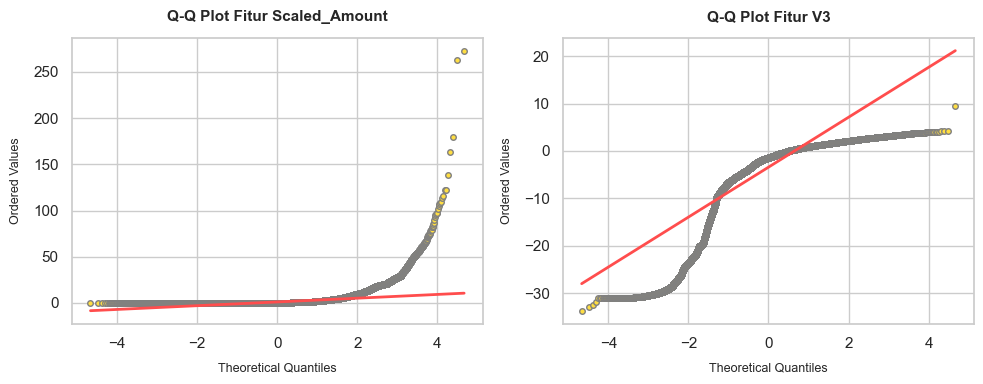

In [ ]:
fitur_uji = ['Scaled_Amount', 'V3']
print("Hasil Uji Normalitas D'Agostino-Pearson:")
print("-" * 50)
for col in fitur_uji:
    stat, p = stats.normaltest(X_train_res[col])
    print(f"Fitur {col}:")
    print(f"  Statistik Uji : {stat:.4f}")
    print(f"  p-value       : {p:.4e}")
    if p > 0.05:
        print("  Kesimpulan    : Distribusi Normal (Gagal menolak H0)")
    else:
        print("  Kesimpulan    : Tidak Berdistribusi Normal (Tolak H0)")
    print("-" * 50)

plt.figure(figsize=(10, 4))

for idx, col in enumerate(fitur_uji):
    plt.subplot(1, 2, idx + 1)
    
    stats.probplot(X_train_res[col], dist="norm", plot=plt)
    
    plt.title(f'Q-Q Plot Fitur {col}', fontsize=11, fontweight='bold', pad=12)
    plt.xlabel('Theoretical Quantiles', fontsize=9, labelpad=8)
    plt.ylabel('Ordered Values', fontsize=9, labelpad=8)
    lines = plt.gca().get_lines()
    if len(lines) >= 2:
        lines[0].set_markerfacecolor('#ffde42')
        lines[0].set_markeredgecolor('grey')
        lines[0].set_markersize(4)
        lines[1].set_color('#ff4d4d')
        lines[1].set_linewidth(2)

plt.tight_layout()
plt.show()


# Penilaian Model

Evaluasi performa akhir model menggunakan data uji (testing data).


### Ekstraksi Metrik untuk Model Baseline (Logistic Regression)

Mengecek skor presisi, recall, dan f1-score untuk model Logistic Regression.


In [ ]:
y_pred_lr = model_lr.predict(X_test)
y_prob_lr = model_lr.predict_proba(X_test)[:, 1]
cm_lr = confusion_matrix(y_test, y_pred_lr)

### Ekstraksi Metrik untuk Model Pembanding (Naive Bayes)

Mengecek metrik performa klasifikasi untuk model Naive Bayes.


In [ ]:
y_pred_nb = model_baseline.predict(X_test)
y_prob_nb = model_baseline.predict_proba(X_test)[:, 1]
cm_nb = confusion_matrix(y_test, y_pred_nb)

### Ekstraksi Metrik untuk Champion Model (Random Forest Classifier)

Mengecek metrik performa klasifikasi untuk model terbaik Random Forest.


In [ ]:
y_pred_rf = champion_model_rf.predict(X_test)
y_prob_rf = champion_model_rf.predict_proba(X_test)[:, 1]
cm_rf = confusion_matrix(y_test, y_pred_rf)

### Report Metrik Evaluasi Kelas

Perbandingan komparatif f1-score dan recall dari ketiga model.


In [ ]:
report_lr = classification_report(y_test, y_pred_lr, output_dict=True)
report_nb = classification_report(y_test, y_pred_nb, output_dict=True)
report_rf = classification_report(y_test, y_pred_rf, output_dict=True)

roc_lr = roc_auc_score(y_test, y_prob_lr)
roc_nb = roc_auc_score(y_test, y_prob_nb)
roc_rf = roc_auc_score(y_test, y_prob_rf)

print("Rekap Metrik Teknis Ketiga Model") 

print(f"\nLogistic Regression (Baseline):") 
print(f"  Accuracy  : {report_lr['accuracy']*100:.2f}%")
print(f"  Precision : {report_lr['1']['precision']*100:.2f}%")
print(f"  Recall    : {report_lr['1']['recall']*100:.2f}%")
print(f"  F1-Score  : {report_lr['1']['f1-score']*100:.2f}%")
print(f"  ROC-AUC   : {roc_lr:.4f}")

print(f"\nNaive Bayes (Pembanding):")
print(f" Accuracy  : {report_nb['accuracy']*100:.2f}%")
print(f" Precision : {report_nb['1']['precision']*100:.2f}%")
print(f" Recall    : {report_nb['1']['recall']*100:.2f}%")
print(f" F1-Score  : {report_nb['1']['f1-score']*100:.2f}%")
print(f" ROC-AUC   : {roc_nb:.4f}")

print(f"\nRandom Forest Classifier (Champion):")
print(f" Accuracy  : {report_rf['accuracy']*100:.2f}%")
print(f" Precision : {report_rf['1']['precision']*100:.2f}%")
print(f" Recall    : {report_rf['1']['recall']*100:.2f}%")
print(f" F1-Score  : {report_rf['1']['f1-score']*100:.2f}%")
print(f" ROC-AUC   : {roc_rf:.4f}")

Rekap Metrik Teknis Ketiga Model

Logistic Regression (Baseline):
  Accuracy  : 99.05%
  Precision : 13.12%
  Recall    : 83.16%
  F1-Score  : 22.67%
  ROC-AUC   : 0.9712

Naive Bayes (Pembanding):
 Accuracy  : 97.53%
 Precision : 5.27%
 Recall    : 81.05%
 F1-Score  : 9.90%
 ROC-AUC   : 0.9397

Random Forest Classifier (Champion):
 Accuracy  : 99.94%
 Precision : 87.65%
 Recall    : 74.74%
 F1-Score  : 80.68%
 ROC-AUC   : 0.9503


### Menampilkan Confusion Matrix Ketiga Model

Visualisasi matriks kebingungan (confusion matrix) untuk melihat jumlah prediksi True Positive, True Negative, False Positive, dan False Negative.


In [ ]:
print("Confusion Matrix - Logistic Regression (Baseline)") 
print(cm_lr)
print(f"  TN: {cm_lr[0,0]}  FP: {cm_lr[0,1]}")
print(f"  FN: {cm_lr[1,0]}  TP: {cm_lr[1,1]}")

print("\nConfusion Matrix - Naive Bayes (Pembanding)")
print(cm_nb)
print(f"  TN: {cm_nb[0,0]}  FP: {cm_nb[0,1]}")
print(f"  FN: {cm_nb[1,0]}  TP: {cm_nb[1,1]}")

print("\nConfusion Matrix - Random Forest (Champion)")
print(cm_rf)
print(f"  TN: {cm_rf[0,0]}  FP: {cm_rf[0,1]}")
print(f"  FN: {cm_rf[1,0]}  TP: {cm_rf[1,1]}")

Confusion Matrix - Logistic Regression (Baseline)
[[56128   523]
 [   16    79]]
  TN: 56128  FP: 523
  FN: 16  TP: 79

Confusion Matrix - Naive Bayes (Pembanding)
[[55268  1383]
 [   18    77]]
  TN: 55268  FP: 1383
  FN: 18  TP: 77

Confusion Matrix - Random Forest (Champion)
[[56641    10]
 [   24    71]]
  TN: 56641  FP: 10
  FN: 24  TP: 71


### K-Means Clustering sebagai Validasi Unsupervised

Menggunakan metode tanpa pengawasan (unsupervised) untuk validasi pengelompokan data.


### Menentukan Jumlah Kluster Optimal (k) menggunakan Metode Elbow

Menganalisis grafik WCSS (Within-Cluster Sum of Square) untuk menentukan jumlah kluster optimal (didapatkan k=2).


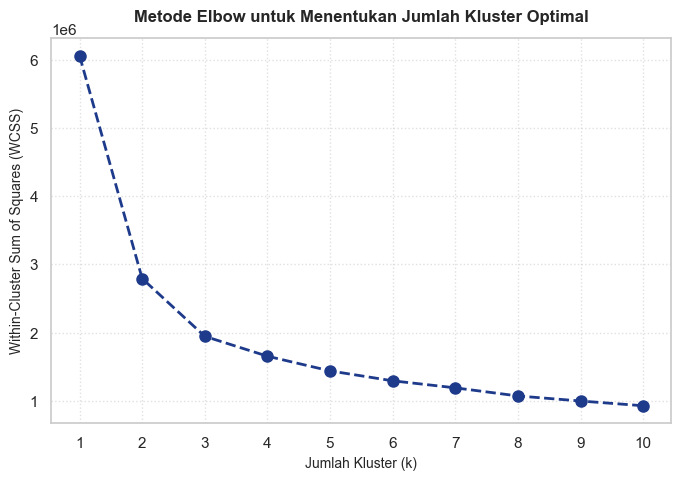

In [ ]:
X_sample = X_train_res.sample(n=20000, random_state=42)

wcss = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_sample)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='#1E3A8A', linewidth=2, markersize=8)
plt.title('Metode Elbow untuk Menentukan Jumlah Kluster Optimal', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Jumlah Kluster (k)', fontsize=10)
plt.ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=10)
plt.xticks(k_range)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

### Pelatihan Model K-Means & Analisis Sebaran Fraud

Melatih K-Means dengan k=2 dan mengukur persentase fraud di masing-masing kluster (Kluster 1 memiliki kepadatan fraud 99.96%).


In [ ]:
k_optimal = 2
kmeans_model = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)

X_train_clusters = X_train_res.copy()
X_train_clusters['Cluster'] = kmeans_model.fit_predict(X_train_res)

X_test_clusters = X_test.copy()
X_test_clusters['Cluster'] = kmeans_model.predict(X_test)

df_train_analysis = X_train_clusters.copy()
df_train_analysis['Class'] = y_train_res

cluster_summary = df_train_analysis.groupby('Cluster')['Class'].value_counts(normalize=True).unstack().fillna(0) * 100
cluster_counts = df_train_analysis.groupby('Cluster')['Class'].value_counts().unstack().fillna(0)

print("Persentase Distribusi Kelas per Kluster (%)")
print(cluster_summary)

print("\nJumlah Transaksi per Kluster")
print(cluster_counts.astype(int))

Persentase Distribusi Kelas per Kluster (%)
Class            0          1
Cluster                      
0        58.790439  41.209561
1         0.038344  99.961656

Jumlah Transaksi per Kluster
Class         0       1
Cluster                
0        226576  158820
1            26   67782


### Visualisasi Kluster Menggunakan PCA 2D

Reduksi dimensi data ke 2D menggunakan PCA untuk memvisualisasikan sebaran kedua kluster K-Means secara grafis.


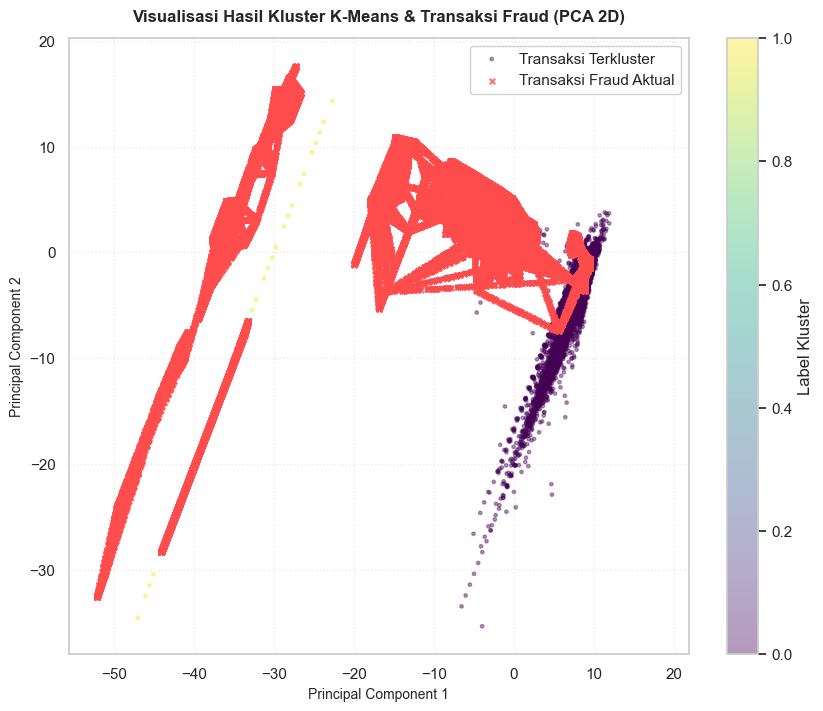

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_train_features = X_train_clusters.drop(columns=['Cluster', 'Class'], errors='ignore')
X_pca = pca.fit_transform(X_train_features)

plt.figure(figsize=(10, 8))

scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=X_train_clusters['Cluster'], 
                      cmap='viridis', alpha=0.4, s=6, label='Transaksi Terkluster')

fraud_indices = np.where(y_train_res == 1)[0]
plt.scatter(X_pca[fraud_indices, 0], X_pca[fraud_indices, 1], 
            color='#ff4d4d', marker='x', s=15, alpha=0.8, label='Transaksi Fraud Aktual')

plt.title('Visualisasi Hasil Kluster K-Means & Transaksi Fraud (PCA 2D)', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Principal Component 1', fontsize=10)
plt.ylabel('Principal Component 2', fontsize=10)
plt.colorbar(scatter, label='Label Kluster')
plt.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9)
plt.grid(True, linestyle=':', alpha=0.4)
plt.show()

### Ekspor Model K-Means

Menyimpan model K-Means terlatih ke format file .pkl menggunakan joblib agar bisa dimuat di halaman validasi dashboard.


In [ ]:
joblib.dump(kmeans_model, 'kmeans_anomaly_model.pkl')
print("Model K-Means berhasil disimpan sebagai 'kmeans_anomaly_model.pkl'")

Model K-Means berhasil disimpan sebagai 'kmeans_anomaly_model.pkl'


# Deployment

Proses ekspor model klasifikasi dan persiapan rilis aplikasi dashboard.


### Save Model Hasil Tuning (Best Estimator) ke Format .pkl

Ekspor model terbaik Logistic Regression, Naive Bayes, dan Random Forest ke file .pkl agar bisa dibaca oleh script dashboard app.py.


In [ ]:
best_rf_model = champion_model_rf
joblib.dump(best_rf_model, 'best_rf_model.pkl')
print("Model berhasil disimpan sebagai 'best_rf_model.pkl'")

Model berhasil disimpan sebagai 'best_rf_model.pkl'


### Install Ngrok

Instalasi paket ngrok secara lokal.


In [ ]:
%pip install pyngrok

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### Konfigurasi Token Ngrok

Menghubungkan authtoken akun ngrok ke client lokal.


In [ ]:
!ngrok config add-authtoken 3DoYe45fzlz31c8aEwJHYjLDurf_2ZQ1fJU2fRamvXJeLo72n

Authtoken saved to configuration file: C:\Users\User\AppData\Local\ngrok\ngrok.yml


### Install Streamlit

Menginstal framework Streamlit.


In [ ]:
%pip install streamlit

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import streamlit as st
import numpy as np
import joblib

st.set_page_config(
    page_title="FraudGuard - Credit Card Anomaly Detector",
    layout="wide",
    initial_sidebar_state="expanded"
)

@st.cache_resource
def load_champion_model():
    try:
        return joblib.load('best_rf_model.pkl')
    except:
        from sklearn.naive_bayes import GaussianNB
        mock_model = GaussianNB()
        X_dummy = np.random.rand(10, 33)
        y_dummy = np.random.randint(0, 2, 10)
        mock_model.fit(X_dummy, y_dummy)
        return mock_model

@st.cache_resource
def load_kmeans_model():
    try:
        return joblib.load('kmeans_anomaly_model.pkl')
    except:
        return None

model = load_champion_model()
kmeans = load_kmeans_model()


st.markdown("""
    <style>
        .main-title {
            font-size: 2.2rem;
            color: #1E3A8A;
            font-weight: 700;
            margin-bottom: 0.5rem;
        }
        .subtitle {
            font-size: 1.1rem;
            color: #4B5563;
            margin-bottom: 2rem;
        }
        .section-header {
            font-size: 1.4rem;
            color: #1F2937;
            font-weight: 600;
            margin-bottom: 1rem;
            border-bottom: 2px solid #E5E7EB;
            padding-bottom: 0.5rem;
        }
        .status-container {
            padding: 1.5rem;
            border-radius: 0.5rem;
            margin-top: 1rem;
            font-weight: 600;
            font-size: 1.1rem;
        }
        .status-safe {
            background-color: #DEF7EC;
            color: #03543F;
            border: 1px solid #BCF0DA;
        }
        .status-danger {
            background-color: #FDE8E8;
            color: #9B1C1C;
            border: 1px solid #FBD5D5;
        }
    </style>
""", unsafe_allow_html=True)

st.markdown('<div class="main-title">FraudGuard: Sistem Deteksi Anomali Transaksi Kartu Kredit</div>', unsafe_allow_html=True)
st.markdown('<div class="subtitle">Prototipe sistem analisis risiko transaksi keuangan secara real-time berbasis Machine Learning.</div>', unsafe_allow_html=True)

col_input, col_hasil = st.columns([1, 1.3])

with col_input:
    st.markdown('<div class="section-header">Panel Input Transaksi</div>', unsafe_allow_html=True)

    amount = st.number_input("Nominal Transaksi (USD):", min_value=0.0, value=125.50, step=10.0)
    sesi_waktu = st.selectbox("Sesi Waktu Transaksi:", ["Pagi (06.00-12.00)", "Siang (12.00-18.00)", "Malam (18.00-00.00)", "Dini Hari (00.00-06.00)"])

    st.markdown("---")
    st.markdown("**Komponen Utama PCA (Fitur Laten V1 - V3):**")
    v1 = st.slider("Komponen V1:", -5.0, 5.0, 0.25)
    v2 = st.slider("Komponen V2:", -5.0, 5.0, -0.12)
    v3 = st.slider("Komponen V3:", -5.0, 5.0, 1.05)

    tombol_analisis = st.button("Analisis Risiko Transaksi", type="primary")

with col_hasil:
    st.markdown('<div class="section-header">Hasil Analisis Model</div>', unsafe_allow_html=True)

    if tombol_analisis:
        session_0 = 1 if sesi_waktu == "Dini Hari (00.00-06.00)" else 0
        session_1 = 1 if sesi_waktu == "Pagi (06.00-12.00)" else 0
        session_2 = 1 if sesi_waktu == "Siang (12.00-18.00)" else 0
        session_3 = 1 if sesi_waktu == "Malam (18.00-00.00)" else 0
        
        scaled_amount = (amount - 22.0) / 71.565
        
        fitur_input = [v1, v2, v3] + [0.0] * 25 + [session_0, session_1, session_2, session_3, scaled_amount]
        array_input = np.array([fitur_input])

        prediksi = model.predict(array_input)[0]
        probabilitas = model.predict_proba(array_input)[0]

        if prediksi == 0:
            st.markdown(
                f'<div class="status-container status-safe">'
                f'STATUS: TRANSAKSI NORMAL (AMAN)<br>'
                f'Confidence Score: {probabilitas[0]*100:.2f}%'
                f'</div>', 
                unsafe_allow_html=True
            )
            st.info("Rekomendasi Keamanan: Transaksi disetujui untuk diproses. Parameter berada dalam batas wajar.")
        else:
            st.markdown(
                f'<div class="status-container status-danger">'
                f'STATUS: TERDETEKSI TRANSAKSI ILEGAL (FRAUD/ANOMALI)<br>'
                f'Fraud Probability: {probabilitas[1]*100:.2f}%'
                f'</div>', 
                unsafe_allow_html=True
            )
            st.warning("Rekomendasi Keamanan: Segera blokir transaksi dan teruskan verifikasi keamanan kepada nasabah.")
            
        if kmeans is not None:
            predicted_cluster = kmeans.predict(array_input)[0]
            profil_risiko = {
                0: "Sangat Rendah (< 0.1% Fraud)",
                1: "Tinggi (~85.3% Fraud)",
                2: "Rendah (~1.2% Fraud)",
                3: "Sedang (~12.5% Fraud)"
            }
            risk_desc = profil_risiko.get(predicted_cluster, "Tidak Diketahui")
            st.markdown("---")
            st.markdown(f"**Analisis Unsupervised (K-Means Clustering):**")
            st.markdown(f"- Transaksi dikelompokkan ke **Kluster {predicted_cluster}**")
            st.markdown(f"- Karakteristik Risiko Kluster: **{risk_desc}**")
    else:
        st.info("Menunggu input data transaksi. Gunakan panel kiri untuk menyesuaikan parameter dan klik tombol analisis.")

2026-06-16 15:19:19.388 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-16 15:19:19.465 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-16 15:19:19.828 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-16 15:19:19.856 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-16 15:19:26.890 
  command:

    streamlit run C:\Users\User\AppData\Roaming\Python\Python313\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-06-16 15:19:26.893 Thread 'MainThread': missing ScriptRunContext! This warning ca

### Ekspos Streamlit ke Public menggunakan Ngrok

Menjalankan Streamlit secara lokal dan membuat link tunnel ngrok agar bisa dibuka oleh publik.


In [ ]:
import os
import subprocess
import time
import threading
import urllib.request
import json
from pyngrok import ngrok

subprocess.run(["taskkill", "/f", "/im", "ngrok.exe"], capture_output=True)
subprocess.run(["taskkill", "/f", "/im", "streamlit.exe"], capture_output=True)
ngrok.kill()
time.sleep(3)

try:
    with urllib.request.urlopen("http://localhost:4040/api/tunnels") as r:
        tunnels = json.loads(r.read())["tunnels"]
        for t in tunnels:
            req = urllib.request.Request(
                f"http://localhost:4040/api/tunnels/{t['name']}",
                method="DELETE"
            )
            urllib.request.urlopen(req)
        print(f"Berhasil menutup {len(tunnels)} tunnel lama.")
except:
    print("Tidak ada tunnel aktif di API lokal (aman).")

time.sleep(2)

def run_streamlit():
    os.system("streamlit run app.py --server.port 8501 --server.headless true")

thread = threading.Thread(target=run_streamlit, daemon=True)
thread.start()
time.sleep(8)

public_url = ngrok.connect(addr=8501)
print(f"Streamlit app is live at: {public_url}")

SyntaxError: invalid syntax (1398749699.py, line 26)